# Titanic Space
В качестве примера возьмем соревнование Kaggle [Space Titanic](https://www.kaggle.com/competitions/spaceship-titanic/overview/description).

## Data description
- PassengerId - A unique Id for each passenger. Each Id takes the form gggg_pp where gggg indicates a group the passenger is travelling with and pp is their number within the group. People in a group are often family members, but not always.
- HomePlanet - The planet the passenger departed from, typically their planet of permanent residence.
- CryoSleep - Indicates whether the passenger elected to be put into suspended animation for the duration of the voyage. Passengers in cryosleep are confined to their cabins.
- Cabin - The cabin number where the passenger is staying. Takes the form deck/num/side, where side can be either P for Port or S for Starboard.
- Destination - The planet the passenger will be debarking to.
- Age - The age of the passenger.
- VIP - Whether the passenger has paid for special VIP service during the voyage.
- RoomService,
- FoodCourt,
- ShoppingMall,
- Spa,
- VRDeck - Amount the passenger has billed at each of the Spaceship Titanic's many luxury amenities.
- Name - The first and last names of the passenger.
- Transported - Whether the passenger was transported to another dimension. This is the target, the column you are trying to predict.

## Загрузка библиотек

In [1]:
# !pip install catboost

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import accuracy_score, classification_report
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.compose import ColumnTransformer
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, VotingClassifier, StackingClassifier
from sklearn.svm import LinearSVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, RandomizedSearchCV

from scipy.stats import randint, uniform

from catboost import CatBoostClassifier
from xgboost import XGBClassifier

## Загрузка данных


In [3]:
# !wget --no-check-certificate 'https://docs.google.com/uc?export=download&id=1sLmVEAPQQna8OT4o37XiuRXFtONrvC8s' -O data.csv

In [2]:
data = pd.read_csv("data/data.csv")
data.head()

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True


In [3]:
data.columns

Index(['PassengerId', 'HomePlanet', 'CryoSleep', 'Cabin', 'Destination', 'Age',
       'VIP', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck',
       'Name', 'Transported'],
      dtype='object')

Посмотрим на типы данных.

In [4]:
data.dtypes.value_counts()

object     7
float64    6
bool       1
Name: count, dtype: int64

In [5]:
data.dtypes

PassengerId      object
HomePlanet       object
CryoSleep        object
Cabin            object
Destination      object
Age             float64
VIP              object
RoomService     float64
FoodCourt       float64
ShoppingMall    float64
Spa             float64
VRDeck          float64
Name             object
Transported        bool
dtype: object

In [7]:
data.shape[0]

8693

In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8693 entries, 0 to 8692
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   PassengerId   8693 non-null   object 
 1   HomePlanet    8492 non-null   object 
 2   CryoSleep     8476 non-null   object 
 3   Cabin         8494 non-null   object 
 4   Destination   8511 non-null   object 
 5   Age           8514 non-null   float64
 6   VIP           8490 non-null   object 
 7   RoomService   8512 non-null   float64
 8   FoodCourt     8510 non-null   float64
 9   ShoppingMall  8485 non-null   float64
 10  Spa           8510 non-null   float64
 11  VRDeck        8505 non-null   float64
 12  Name          8493 non-null   object 
 13  Transported   8693 non-null   bool   
dtypes: bool(1), float64(6), object(7)
memory usage: 891.5+ KB


In [8]:
data.describe()

,Age,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck
count,8514.000000,8512.000000,8510.000000,8485.000000,8510.000000,8505.000000
mean,28.827930,224.687617,458.077203,173.729169,311.138778,304.854791
std,14.489021,666.717663,1611.489240,604.696458,1136.705535,1145.717189
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,19.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,27.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,38.000000,47.000000,76.000000,27.000000,59.000000,46.000000
max,79.000000,14327.000000,29813.000000,23492.000000,22408.000000,24133.000000


Разделим данные на трейн и тест.

In [9]:
X_train, X_test, y_train, y_test = train_test_split(data[data.columns[:-1]], data[data.columns[-1]], random_state= 42)

In [10]:
X_train.columns

Index(['PassengerId', 'HomePlanet', 'CryoSleep', 'Cabin', 'Destination', 'Age',
       'VIP', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck',
       'Name'],
      dtype='object')

In [11]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((6519, 13), (2174, 13), (6519,), (2174,))

### Обработка пропущенных значений

In [12]:
# Number of nulls
pd.DataFrame(X_train.isnull().sum(),
            columns = ['missing_count']) \
.assign(missing_pct = lambda x: x['missing_count']/X_train.shape[0]*100).astype(float).round(1)

,missing_count,missing_pct
PassengerId,0.0,0.0
HomePlanet,155.0,2.4
CryoSleep,165.0,2.5
Cabin,150.0,2.3
Destination,132.0,2.0
Age,142.0,2.2
VIP,159.0,2.4
RoomService,120.0,1.8
FoodCourt,133.0,2.0
ShoppingMall,154.0,2.4


In [13]:
float(pd.DataFrame(X_train.isnull().sum(),
            columns = ['missing_count']) \
.assign(missing_pct = lambda x: x['missing_count']/X_train.shape[0]*100) \
    .sum()['missing_pct'])

26.353735235465564

Визуализируем долю пропусков для колонок.

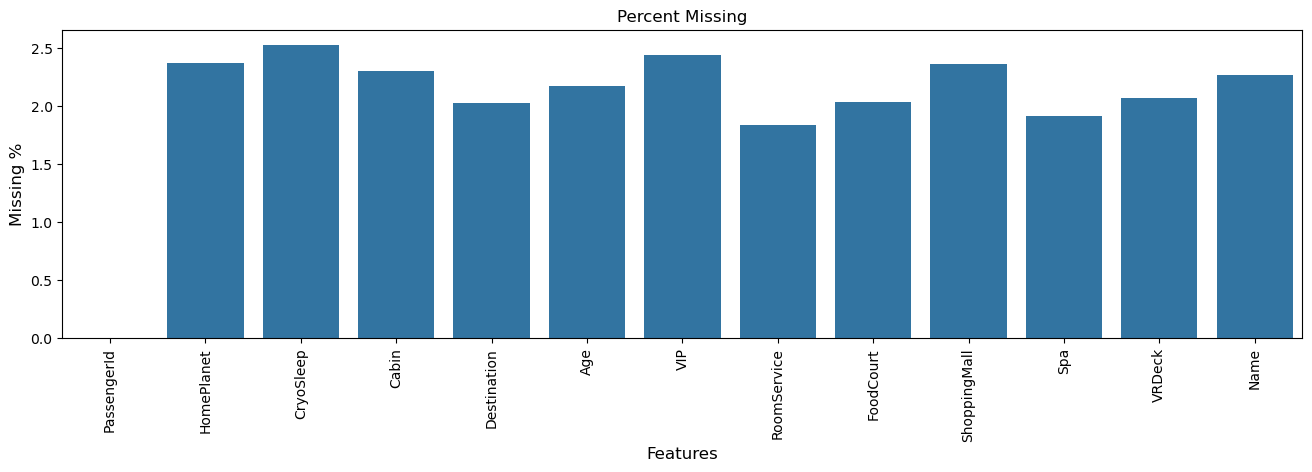

In [14]:
# Let's plot number of missing in each column

nan_train_X = ((X_train.isna().sum() / X_train.shape[0]*100)).reset_index()
nan_train_X.columns=['feature', 'nan_percent']

plt.figure(figsize=(16,4))
sns.barplot(x=nan_train_X['feature'], y=nan_train_X['nan_percent'])
plt.title('Percent Missing')
plt.ylabel('Missing %', fontsize=12)
plt.xlabel('Features', fontsize=12)
plt.xticks(rotation=90)
plt.show()

In [15]:
round(1 - X_train.dropna().shape[0]/X_train.shape[0], 2)*100

24.0

 Если выкинуть данные с пропусками из датасета, то мы потераем около 24% данных, что слишком много.

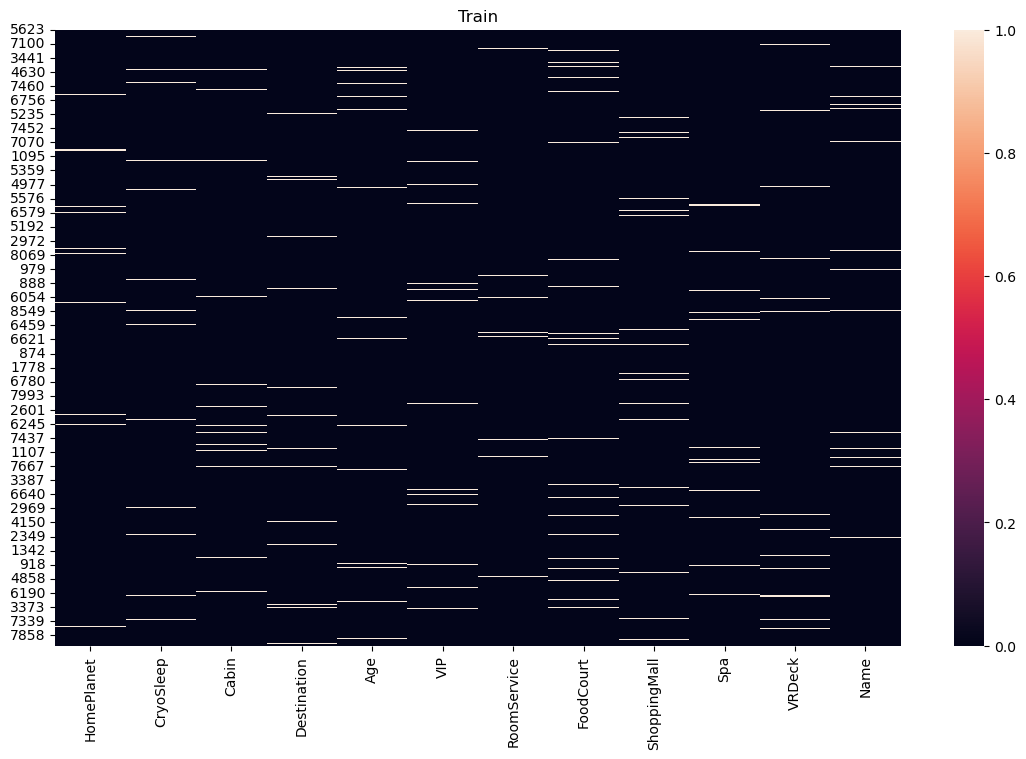

In [16]:
fig = plt.figure(figsize=(30, 8))
ax = fig.add_subplot(1, 2, 1)
ax = sns.heatmap(X_train[X_train.columns[1:]].isnull())
ax.title.set_text('Train')
plt.show()

## Обработка признаков



In [19]:
X_train.head()

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name
5623,5981_01,Mars,False,F/1140/S,TRAPPIST-1e,27.0,False,441.0,0.0,397.0,471.0,0.0,Harz Quart
5253,5606_01,Europa,True,B/213/S,55 Cancri e,45.0,False,0.0,0.0,0.0,0.0,0.0,Algor Paterpad
478,0515_01,Europa,True,B/20/S,TRAPPIST-1e,50.0,False,0.0,0.0,0.0,0.0,0.0,Alramix Swinvul
1352,1425_02,Earth,True,G/220/P,TRAPPIST-1e,1.0,False,0.0,0.0,0.0,0.0,0.0,Mael Adavisons
5344,5713_01,Earth,False,G/915/P,TRAPPIST-1e,42.0,False,0.0,29.0,317.0,434.0,45.0,Lawren Blangibson


### PassangerID

Разделим ID пассажира на две части.

In [17]:
#Find Group and No Pass
X_train[["G_Passenger", 'N_Passenger']] = X_train["PassengerId"].str.split('_', expand=True).astype('int')

#Set the Index
X_train.set_index('PassengerId',inplace=True)


X_train.head()

,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,G_Passenger,N_Passenger
PassengerId,,,,,,,,,,,,,,
5981_01,Mars,False,F/1140/S,TRAPPIST-1e,27.0,False,441.0,0.0,397.0,471.0,0.0,Harz Quart,5981,1
5606_01,Europa,True,B/213/S,55 Cancri e,45.0,False,0.0,0.0,0.0,0.0,0.0,Algor Paterpad,5606,1
0515_01,Europa,True,B/20/S,TRAPPIST-1e,50.0,False,0.0,0.0,0.0,0.0,0.0,Alramix Swinvul,515,1
1425_02,Earth,True,G/220/P,TRAPPIST-1e,1.0,False,0.0,0.0,0.0,0.0,0.0,Mael Adavisons,1425,2
5713_01,Earth,False,G/915/P,TRAPPIST-1e,42.0,False,0.0,29.0,317.0,434.0,45.0,Lawren Blangibson,5713,1


In [18]:
categorical_features = X_train.select_dtypes(include = ['object']).columns.to_list()
categorical_features

['HomePlanet', 'CryoSleep', 'Cabin', 'Destination', 'VIP', 'Name']

### Cabin

Разделим поле на несколько частей.

In [19]:
# Fill nan special values and split the field for three different fields

X_train['Cabin'] = X_train['Cabin'].fillna('X/9999/X')
X_test['Cabin'] = X_test['Cabin'].fillna('X/9999/X')

X_train['Cabin_1'] = X_train['Cabin'].str.split("/",expand=True).iloc[:,0]
X_train['Cabin_2'] = X_train.Cabin.str.split("/",expand=True).iloc[:,1]
X_train['Cabin_3'] = X_train.Cabin.str.split("/",expand=True).iloc[:,2]

X_test['Cabin_1'] = X_test.Cabin.str.split("/",expand=True).iloc[:,0]
X_test['Cabin_2'] = X_test.Cabin.str.split("/",expand=True).iloc[:,1]
X_test['Cabin_3'] = X_test.Cabin.str.split("/",expand=True).iloc[:,2]


In [20]:
X_train['Cabin'] = X_train['Cabin'].fillna('X/9999/X')
X_test['Cabin'] = X_test['Cabin'].fillna('X/9999/X')

# заполняем столбцы
for i, _ in enumerate(X_train['Cabin'].str.split("/",expand=True)):
    X_train['Cabin_' + str(i+1)] = X_train['Cabin'].str.split("/", expand=True)[i]
    X_test['Cabin_' + str(i+1)] = X_test['Cabin'].str.split("/", expand=True)[i]

In [21]:
X_train.drop(['Cabin'], axis=1, inplace=True)
X_test.drop(['Cabin'], axis=1, inplace=True)

In [22]:
X_train.head()

,HomePlanet,CryoSleep,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,G_Passenger,N_Passenger,Cabin_1,Cabin_2,Cabin_3
PassengerId,,,,,,,,,,,,,,,,
5981_01,Mars,False,TRAPPIST-1e,27.0,False,441.0,0.0,397.0,471.0,0.0,Harz Quart,5981,1,F,1140,S
5606_01,Europa,True,55 Cancri e,45.0,False,0.0,0.0,0.0,0.0,0.0,Algor Paterpad,5606,1,B,213,S
0515_01,Europa,True,TRAPPIST-1e,50.0,False,0.0,0.0,0.0,0.0,0.0,Alramix Swinvul,515,1,B,20,S
1425_02,Earth,True,TRAPPIST-1e,1.0,False,0.0,0.0,0.0,0.0,0.0,Mael Adavisons,1425,2,G,220,P
5713_01,Earth,False,TRAPPIST-1e,42.0,False,0.0,29.0,317.0,434.0,45.0,Lawren Blangibson,5713,1,G,915,P


### Destination

Заполним пропуски неизвестным значением

In [23]:
X_train['Destination'] = X_train['Destination'].fillna('Unknown')
X_test['Destination'] = X_test['Destination'].fillna('Unknown')


### HomePlanet

Заполняем пропуски самым частым значением.

In [24]:
imp = SimpleImputer(strategy="most_frequent")

X_train[['HomePlanet']] = imp.fit_transform(X_train[['HomePlanet']])
X_test[['HomePlanet']] = imp.transform(X_test[['HomePlanet']])

### CryoSleep

Заполняем пропуски самым частым значением.

In [25]:
imp = SimpleImputer(strategy="most_frequent")

X_train[['CryoSleep']] = imp.fit_transform(X_train[['CryoSleep']])
X_test[['CryoSleep']] = imp.transform(X_test[['CryoSleep']])

### VIP

Заполняем пропуски самым частым значением.

In [26]:
imp = SimpleImputer(strategy="most_frequent")

X_train[['VIP']] = imp.fit_transform(X_train[['VIP']])
X_test[['VIP']]=imp.transform(X_test[['VIP']])

### Age

Заполняем медианным значением.

In [27]:
imp = SimpleImputer(strategy="median")

X_train[['Age']]=imp.fit_transform(X_train[['Age']])
X_test[['Age']]=imp.transform(X_test[['Age']])

### RoomService

Заполняем 0.

In [28]:
#Fill Na with 0
imp = SimpleImputer(strategy='constant', fill_value=0)

X_train[['RoomService']]=imp.fit_transform(X_train[['RoomService']])
X_test[['RoomService']]=imp.transform(X_test[['RoomService']])

### FoodCourt

Заполняем 0.

In [29]:
imp = SimpleImputer(strategy='constant', fill_value=0)

X_train[['FoodCourt']] = imp.fit_transform(X_train[['FoodCourt']])
X_test[['FoodCourt']] = imp.transform(X_test[['FoodCourt']])

### ShoppingMall

Заполняем 0.

In [30]:
imp = SimpleImputer(strategy='constant', fill_value=0)

X_train[['ShoppingMall']] = imp.fit_transform(X_train[['ShoppingMall']])
X_test[['ShoppingMall']] = imp.transform(X_test[['ShoppingMall']])

### Spa

Заполняем 0.

In [31]:
imp = SimpleImputer(strategy='constant', fill_value=0)

X_train[['Spa']] = imp.fit_transform(X_train[['Spa']])
X_test[['Spa']] = imp.transform(X_test[['Spa']])

### VRDeck

Заполняем 0.

In [32]:
imp = SimpleImputer(strategy='constant', fill_value=0)
X_train[['VRDeck']] = imp.fit_transform(X_train[['VRDeck']])
X_test[['VRDeck']] = imp.transform(X_test[['VRDeck']])

### Name

In [33]:
X_train.drop('Name', axis=1, inplace=True)
X_test.drop('Name', axis=1, inplace=True)

### Итоговая проверка.

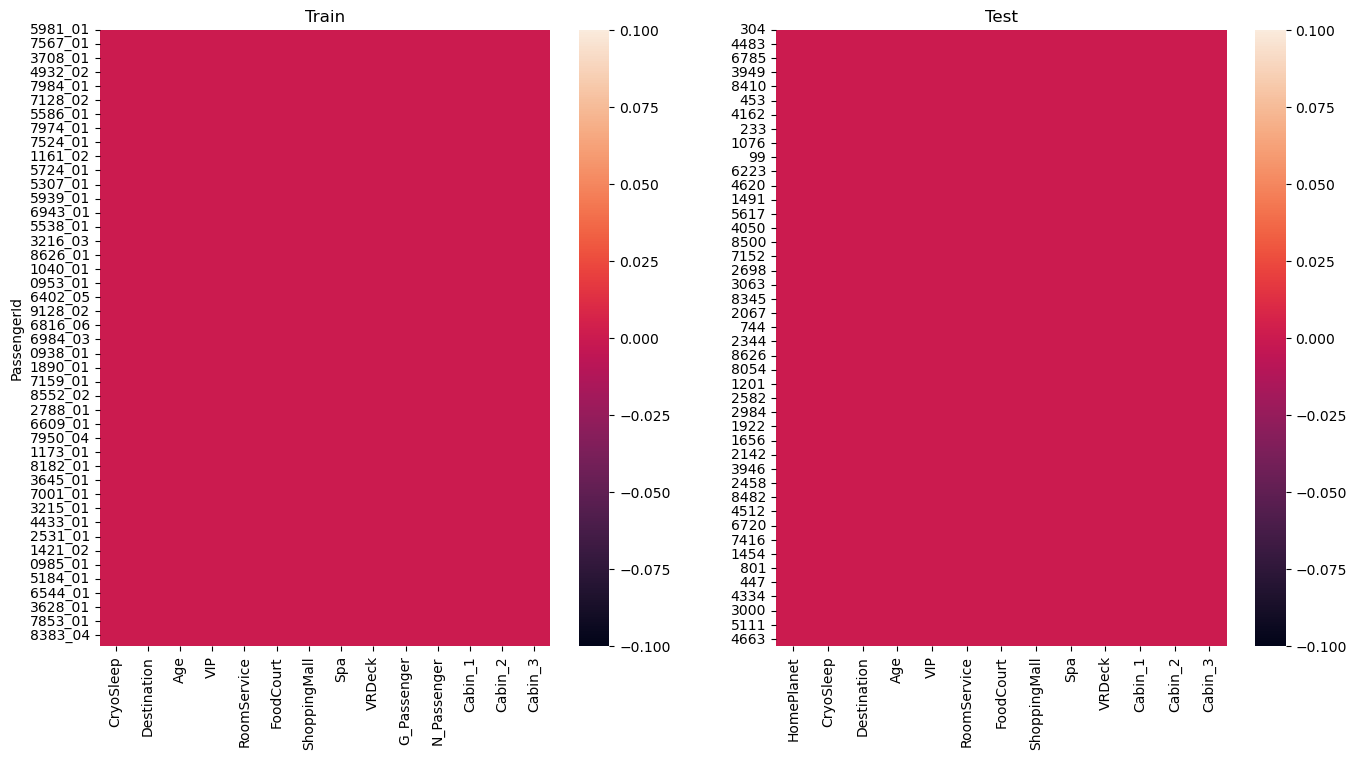

In [34]:
fig = plt.figure(figsize=(16, 8))
ax = fig.add_subplot(1, 2, 1)
ax = sns.heatmap(X_train[X_train.columns[1:]].isnull())
ax.title.set_text('Train')

ax = fig.add_subplot(1, 2, 2)
ax = sns.heatmap(X_test[X_test.columns[1:]].isnull())
ax.title.set_text('Test')

plt.show()

**Вопрос:** Как можно улучшить решение выше?

## Pipeline

In [35]:
data = pd.read_csv("data/data.csv")

data[["G_Passenger", 'N_Passenger']] = data["PassengerId"].str.split('_', expand=True).astype('int')

data.set_index('PassengerId',inplace=True)
data.drop('Name', axis=1, inplace=True)
data.shape


(8693, 14)

In [37]:
data.columns

Index(['HomePlanet', 'CryoSleep', 'Cabin', 'Destination', 'Age', 'VIP',
       'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck',
       'Transported', 'G_Passenger', 'N_Passenger'],
      dtype='object')

### Feature engineering

In [38]:
#Total Spend
data['total_spent']= data['RoomService']+ data['FoodCourt']+ data['ShoppingMall']+ data['Spa']+ data['VRDeck']

In [39]:
#Age Group Pass
data['AgeGroup'] = pd.cut(data['Age'], bins=[0, 5, 12, 18, 50, 150], labels=['Baby','Child','Teen', 'Adult','Elderly'])


In [40]:
data['Cabin'] = data['Cabin'].fillna('X/9999/X')

for i, _ in enumerate(data['Cabin'].str.split("/",expand=True)):
    data['Cabin_' + str(i+1)] = data['Cabin'].str.split("/", expand=True)[i]

data.drop('Cabin', axis=1, inplace=True)

data['Cabin_2'] = data['Cabin_2'].astype(float)


In [41]:
data.head()

,HomePlanet,CryoSleep,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Transported,G_Passenger,N_Passenger,total_spent,AgeGroup,Cabin_1,Cabin_2,Cabin_3
PassengerId,,,,,,,,,,,,,,,,,,
0001_01,Europa,False,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,False,1,1,0.0,Adult,B,0.0,P
0002_01,Earth,False,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,True,2,1,736.0,Adult,F,0.0,S
0003_01,Europa,False,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,False,3,1,10383.0,Elderly,A,0.0,S
0003_02,Europa,False,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,False,3,2,5176.0,Adult,A,0.0,S
0004_01,Earth,False,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,True,4,1,1091.0,Teen,F,1.0,S


In [42]:
data['CryoSleep'] = data['CryoSleep'].astype(bool)
data['VIP'] = data['VIP'].astype(bool)

In [43]:
numerical_features = data.select_dtypes(include=np.number).columns.tolist()
categorical_features = data.select_dtypes(include = ['object']).columns.to_list()

In [44]:
numerical_features

['Age',
 'RoomService',
 'FoodCourt',
 'ShoppingMall',
 'Spa',
 'VRDeck',
 'G_Passenger',
 'N_Passenger',
 'total_spent',
 'Cabin_2']

In [45]:
categorical_features

['HomePlanet', 'Destination', 'Cabin_1', 'Cabin_3']

### Разделим датасет

In [48]:
X_train, X_test, y_train, y_test = train_test_split(data.drop('Transported', axis=1), data['Transported'], random_state = 42)

### Нормировка для численных признаков

In [49]:
scaler = StandardScaler()
ohe=OneHotEncoder(sparse_output=False)
data_train_scaled = scaler.fit_transform(X_train[numerical_features])
data_train_ohe = ohe.fit_transform(X_train[categorical_features])

**Вопрос:** Что еще можно улучшить?

In [50]:
#   Для категориальных - применяем SimpleImputer, а затем StandardScaler
numerical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer()),
    ("scaler", StandardScaler()),
    ("fs", SelectKBest(score_func=f_classif, k="all")),
])

#   Для категориальных - применяем SimpleImputer, а затем OneHotEncoder
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore")),
])

# Собираем воедино трансформеры для числовых и категориальных признаков
data_transformer = ColumnTransformer(transformers=[
    ("numerical", numerical_transformer, numerical_features),
    ("categorical", categorical_transformer, categorical_features),
])

# Создание конвейера препроцессора, который сначала преобразует данные
preprocessor = Pipeline(steps=[("data_transformer", data_transformer)])

classifier_pipline = Pipeline(
    steps=[("preprocessor", preprocessor),
           ("classifier", LogisticRegression())])

classifier_pipline

Pipeline(steps=[('preprocessor',
                 Pipeline(steps=[('data_transformer',
                                  ColumnTransformer(transformers=[('numerical',
                                                                   Pipeline(steps=[('imputer',
                                                                                    SimpleImputer()),
                                                                                   ('scaler',
                                                                                    StandardScaler()),
                                                                                   ('fs',
                                                                                    SelectKBest(k='all'))]),
                                                                   ['Age',
                                                                    'RoomService',
                                                                    'FoodCourt',
                                                                    'ShoppingMall',
                                                                    'Spa',
                                                                    'VRDeck',
                                                                    'G_Passenger',
                                                                    'N_Passenger',
                                                                    'total_spent',
                                                                    'Cabin_2']),
                                                                  ('categorical',
                                                                   Pipeline(steps=[('imputer',
                                                                                    SimpleImputer(strategy='most_frequent')),
                                                                                   ('onehot',
                                                                                    OneHotEncoder(handle_unknown='ignore'))]),
                                                                   ['HomePlanet',
                                                                    'Destination',
                                                                    'Cabin_1',
                                                                    'Cabin_3'])]))])),
                ('classifier', LogisticRegression())])

In [51]:
target = ['Transported']
all_features = data.drop('Transported', axis=1).columns.tolist()

In [52]:
data_train, data_test = train_test_split(data[all_features + target], test_size=0.2, stratify=data[target], random_state = 42)

## Model<a class="anchor" id="model"></a>

In [53]:
classifier_pipline.fit(data_train[all_features], data_train[target].iloc[:,0])

preds = classifier_pipline.predict(data_test[all_features])

print(accuracy_score(data_test[target], preds))

0.7941345600920069


### Заменим классификатор

In [54]:
classifier_pipline = Pipeline(
    steps=[("preprocessor", preprocessor),
           ("classifier", CatBoostClassifier(iterations=3000,
                         eval_metric='Accuracy',
                        verbose=0))])
classifier_pipline

Pipeline(steps=[('preprocessor',
                 Pipeline(steps=[('data_transformer',
                                  ColumnTransformer(transformers=[('numerical',
                                                                   Pipeline(steps=[('imputer',
                                                                                    SimpleImputer()),
                                                                                   ('scaler',
                                                                                    StandardScaler()),
                                                                                   ('fs',
                                                                                    SelectKBest(k='all'))]),
                                                                   ['Age',
                                                                    'RoomService',
                                                                    'FoodCourt',
                                                                    'ShoppingMall',
                                                                    'Spa',
                                                                    'VRDeck',
                                                                    'G_Passenger',
                                                                    'N_Passenger',
                                                                    'total_spent',
                                                                    'Cabin_2']),
                                                                  ('categorical',
                                                                   Pipeline(steps=[('imputer',
                                                                                    SimpleImputer(strategy='most_frequent')),
                                                                                   ('onehot',
                                                                                    OneHotEncoder(handle_unknown='ignore'))]),
                                                                   ['HomePlanet',
                                                                    'Destination',
                                                                    'Cabin_1',
                                                                    'Cabin_3'])]))])),
                ('classifier',
                 <catboost.core.CatBoostClassifier object at 0x17a053f20>)])

In [55]:
classifier_pipline.fit(data_train[all_features], data_train[target].iloc[:,0])

preds = classifier_pipline.predict(data_test[all_features]).astype(bool)    #type: ignore

print(accuracy_score(data_test[target], preds))

0.8228867165037378


## Добавим ансамбль

In [56]:
VotingClassifier

sklearn.ensemble._voting.VotingClassifier

In [58]:
clf1 = LogisticRegression(random_state=1)
clf2 = RandomForestClassifier(n_estimators=50, random_state=1)
clf3 = KNeighborsClassifier()

voiting_classifier = VotingClassifier(
    estimators=[("log_regrassion", clf1),
                ("random_forest", clf2),
                ("knn", clf3)]
)
voiting_classifier

VotingClassifier(estimators=[('log_regrassion',
                              LogisticRegression(random_state=1)),
                             ('random_forest',
                              RandomForestClassifier(n_estimators=50,
                                                     random_state=1)),
                             ('knn', KNeighborsClassifier())])

In [59]:
classifier_pipline = Pipeline(
    steps=[("preprocessor", preprocessor),
           ("classifier", voiting_classifier)]
)

classifier_pipline

Pipeline(steps=[('preprocessor',
                 Pipeline(steps=[('data_transformer',
                                  ColumnTransformer(transformers=[('numerical',
                                                                   Pipeline(steps=[('imputer',
                                                                                    SimpleImputer()),
                                                                                   ('scaler',
                                                                                    StandardScaler()),
                                                                                   ('fs',
                                                                                    SelectKBest(k='all'))]),
                                                                   ['Age',
                                                                    'RoomService',
                                                                    'FoodCourt',
                                                                    'ShoppingMall',
                                                                    'Spa',
                                                                    'VRDeck',
                                                                    'G_Passenger',
                                                                    'N_Passenger',
                                                                    'total_spent',
                                                                    'Cabin_2']),
                                                                  ('categorical',
                                                                   Pip...
                                                                                    SimpleImputer(strategy='most_frequent')),
                                                                                   ('onehot',
                                                                                    OneHotEncoder(handle_unknown='ignore'))]),
                                                                   ['HomePlanet',
                                                                    'Destination',
                                                                    'Cabin_1',
                                                                    'Cabin_3'])]))])),
                ('classifier',
                 VotingClassifier(estimators=[('log_regrassion',
                                               LogisticRegression(random_state=1)),
                                              ('random_forest',
                                               RandomForestClassifier(n_estimators=50,
                                                                      random_state=1)),
                                              ('knn',
                                               KNeighborsClassifier())]))])

In [60]:
classifier_pipline.fit(data_train[all_features], data_train[target].iloc[:,0])

preds = classifier_pipline.predict(data_test[all_features]).astype(bool)    #type: ignore

print(accuracy_score(data_test[target], preds))

0.8090856814261069


### Добавим стекинг

In [61]:
estimators = [
    ("Random_Forest", RandomForestClassifier()),
    ("Xgboost", XGBClassifier()),
    ("SVM", LinearSVC()),

]

# построим классификатор используя стекинг и наш список классификаторов
stacking_classifier = StackingClassifier(
    estimators=estimators,
    final_estimator=LogisticRegression(n_jobs=-1, verbose=False),
    n_jobs=-1,
    verbose=True,
)

classifier_pipline = Pipeline(
    steps=[("preprocessor", preprocessor),
           ("classifier", stacking_classifier)]
)

classifier_pipline

Pipeline(steps=[('preprocessor',
                 Pipeline(steps=[('data_transformer',
                                  ColumnTransformer(transformers=[('numerical',
                                                                   Pipeline(steps=[('imputer',
                                                                                    SimpleImputer()),
                                                                                   ('scaler',
                                                                                    StandardScaler()),
                                                                                   ('fs',
                                                                                    SelectKBest(k='all'))]),
                                                                   ['Age',
                                                                    'RoomService',
                                                                    'FoodCourt',
                                                                    'ShoppingMall',
                                                                    'Spa',
                                                                    'VRDeck',
                                                                    'G_Passenger',
                                                                    'N_Passenger',
                                                                    'total_spent',
                                                                    'Cabin_2']),
                                                                  ('categorical',
                                                                   Pip...
                                                               max_bin=None,
                                                               max_cat_threshold=None,
                                                               max_cat_to_onehot=None,
                                                               max_delta_step=None,
                                                               max_depth=None,
                                                               max_leaves=None,
                                                               min_child_weight=None,
                                                               missing=nan,
                                                               monotone_constraints=None,
                                                               multi_strategy=None,
                                                               n_estimators=None,
                                                               n_jobs=None,
                                                               num_parallel_tree=None, ...)),
                                                ('SVM', LinearSVC())],
                                    final_estimator=LogisticRegression(n_jobs=-1,
                                                                       verbose=False),
                                    n_jobs=-1, verbose=True))])

In [62]:
classifier_pipline.fit(data_train[all_features], data_train[target].iloc[:,0])

preds = classifier_pipline.predict(data_test[all_features]).astype(bool)    #type: ignore

print(accuracy_score(data_test[target], preds))

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 10 concurrent workers.
[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 10 concurrent workers.
[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:    0.0s finished
[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:    0.1s finished
[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 10 concurrent workers.
[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:    0.7s finished


0.8200115008625647


## Подбор параметров

In [63]:
# Сетка гиперпараметров для всего pipeline
param_grid = {
    # === Препроцессинг числовых признаков ===
    # стратегия импьютации
    "preprocessor__data_transformer__numerical__imputer__strategy": [
        "mean",
        "median",
    ],
    # выбор количества признаков
    "preprocessor__data_transformer__numerical__fs__k": [
        10,
        "all",
    ],

    # === RandomForest (базовый алгоритм в стекинге) ===
    "classifier__Random_Forest__n_estimators": [100, 300],
    "classifier__Random_Forest__max_depth": [None, 5, 10],

    # === XGBoost ===
    "classifier__Xgboost__n_estimators": [200, 500],
    "classifier__Xgboost__max_depth": [3, 5],

    # === LinearSVC ===
    "classifier__SVM__C": [0.1, 1.0, 10.0],

    # === Мета-модель (LogisticRegression в StackingClassifier) ===
    "classifier__final_estimator__C": [0.1, 1.0, 10.0],
    "classifier__final_estimator__penalty": ["l2"],
    "classifier__final_estimator__solver": ["lbfgs"],
}

In [64]:
# Кросс-валидация
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_search = GridSearchCV(
    estimator=classifier_pipline,
    param_grid=param_grid,
    cv=cv,
    scoring="accuracy",   # при необходимости поменяй на f1, roc_auc и т.п.
    n_jobs=-1,
    verbose=2,
)

In [89]:
# Ооочень долго, всего 4320 расчетов
# лучше не запускать

# grid_search.fit(X_train, y_train)

# print("Лучшие параметры:")
# print(grid_search.best_params_)

# best_model = grid_search.best_estimator_

In [90]:
# preds = best_model.predict(data_test[all_features]).astype(bool)    #type: ignore

# print(accuracy_score(data_test[target], preds))

### Используем

In [66]:
param_distributions = {
    # === Препроцессинг числовых данных ===
    "preprocessor__data_transformer__numerical__imputer__strategy": [
        "mean", "median"
    ],
    "preprocessor__data_transformer__numerical__fs__k": [
        10, 20, "all"
    ],

    # === RandomForest ===
    "classifier__Random_Forest__n_estimators": randint(100, 500),
    "classifier__Random_Forest__max_depth": [None, 5, 10, 20],
    "classifier__Random_Forest__min_samples_split": randint(2, 10),
    "classifier__Random_Forest__min_samples_leaf": randint(1, 5),

    # === XGBoost ===
    "classifier__Xgboost__n_estimators": randint(200, 600),
    "classifier__Xgboost__max_depth": randint(3, 8),
    "classifier__Xgboost__learning_rate": uniform(0.01, 0.2),
    "classifier__Xgboost__subsample": uniform(0.7, 0.3),        # ~0.7–1.0
    "classifier__Xgboost__colsample_bytree": uniform(0.7, 0.3),

    # === LinearSVC ===
    "classifier__SVM__C": uniform(0.01, 10),

    # === Финальный классификатор (логрегрессия) ===
    "classifier__final_estimator__C": uniform(0.01, 10),
    "classifier__final_estimator__solver": ["lbfgs"],
    "classifier__final_estimator__penalty": ["l2"],
}

In [67]:

#   Настройка RandomizedSearchCV
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

random_search = RandomizedSearchCV(
    estimator=classifier_pipline,
    param_distributions=param_distributions,
    n_iter=40,                 # количество случайных наборов параметров
    cv=cv,
    scoring="accuracy",        # можно заменить на f1, roc_auc, etc.
    n_jobs=-1,
    verbose=2,
    random_state=42
)


In [68]:
random_search.fit(X_train, y_train)

print("Лучшие параметры:")
print(random_search.best_params_)

best_model = random_search.best_estimator_

Fitting 5 folds for each of 40 candidates, totalling 200 fits


[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:    0.2s finished
[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:    0.2s finished
[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:    0.2s finished
[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:    0.2s finished
[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:    0.1s finished
[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:    0.1s finished
[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:    0.1s finished
[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:    0.1s finished
[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:    0.1s finished
[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:    0.1s finished
[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:    1.6s finished
[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:    1.6s finished
[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:    1.6s finished
[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:    1.5s finished
[Paral

[CV] END classifier__Random_Forest__max_depth=10, classifier__Random_Forest__min_samples_leaf=4, classifier__Random_Forest__min_samples_split=6, classifier__Random_Forest__n_estimators=370, classifier__SVM__C=7.3299394181140505, classifier__Xgboost__colsample_bytree=0.8795975452591109, classifier__Xgboost__learning_rate=0.0412037280884873, classifier__Xgboost__max_depth=5, classifier__Xgboost__n_estimators=414, classifier__Xgboost__subsample=0.7174250836504598, classifier__final_estimator__C=8.671761457749351, classifier__final_estimator__penalty=l2, classifier__final_estimator__solver=lbfgs, preprocessor__data_transformer__numerical__fs__k=all, preprocessor__data_transformer__numerical__imputer__strategy=median; total time=  12.6s
[CV] END classifier__Random_Forest__max_depth=10, classifier__Random_Forest__min_samples_leaf=4, classifier__Random_Forest__min_samples_split=6, classifier__Random_Forest__n_estimators=370, classifier__SVM__C=7.3299394181140505, classifier__Xgboost__colsampl

[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:   10.4s finished
[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:   10.5s finished


[CV] END classifier__Random_Forest__max_depth=10, classifier__Random_Forest__min_samples_leaf=4, classifier__Random_Forest__min_samples_split=6, classifier__Random_Forest__n_estimators=370, classifier__SVM__C=7.3299394181140505, classifier__Xgboost__colsample_bytree=0.8795975452591109, classifier__Xgboost__learning_rate=0.0412037280884873, classifier__Xgboost__max_depth=5, classifier__Xgboost__n_estimators=414, classifier__Xgboost__subsample=0.7174250836504598, classifier__final_estimator__C=8.671761457749351, classifier__final_estimator__penalty=l2, classifier__final_estimator__solver=lbfgs, preprocessor__data_transformer__numerical__fs__k=all, preprocessor__data_transformer__numerical__imputer__strategy=median; total time=  12.9s
[CV] END classifier__Random_Forest__max_depth=10, classifier__Random_Forest__min_samples_leaf=4, classifier__Random_Forest__min_samples_split=6, classifier__Random_Forest__n_estimators=370, classifier__SVM__C=7.3299394181140505, classifier__Xgboost__colsampl

...

[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:    4.0s finished
/opt/miniconda3/envs/otus_new/lib/python3.12/site-packages/sklearn/feature_selection/_univariate_selection.py:783: UserWarning: k=20 is greater than n_features=10. All the features will be returned.
  warnings.warn(


[CV] END classifier__Random_Forest__max_depth=10, classifier__Random_Forest__min_samples_leaf=4, classifier__Random_Forest__min_samples_split=5, classifier__Random_Forest__n_estimators=195, classifier__SVM__C=3.4180354025301782, classifier__Xgboost__colsample_bytree=0.9792271976810694, classifier__Xgboost__learning_rate=0.18168255036860237, classifier__Xgboost__max_depth=3, classifier__Xgboost__n_estimators=382, classifier__Xgboost__subsample=0.9252613203374491, classifier__final_estimator__C=7.555428740846823, classifier__final_estimator__penalty=l2, classifier__final_estimator__solver=lbfgs, preprocessor__data_transformer__numerical__fs__k=10, preprocessor__data_transformer__numerical__imputer__strategy=median; total time=   5.5s


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 10 concurrent workers.
[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 10 concurrent workers.
[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 10 concurrent workers.
[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:    0.0s finished
[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:    0.2s finished


Лучшие параметры:
{'classifier__Random_Forest__max_depth': 10, 'classifier__Random_Forest__min_samples_leaf': 2, 'classifier__Random_Forest__min_samples_split': 5, 'classifier__Random_Forest__n_estimators': 165, 'classifier__SVM__C': 6.253540481337932, 'classifier__Xgboost__colsample_bytree': 0.7886901057513142, 'classifier__Xgboost__learning_rate': 0.031098851966054122, 'classifier__Xgboost__max_depth': 6, 'classifier__Xgboost__n_estimators': 227, 'classifier__Xgboost__subsample': 0.76553213116505, 'classifier__final_estimator__C': 4.175099478703662, 'classifier__final_estimator__penalty': 'l2', 'classifier__final_estimator__solver': 'lbfgs', 'preprocessor__data_transformer__numerical__fs__k': 20, 'preprocessor__data_transformer__numerical__imputer__strategy': 'mean'}


[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:    1.3s finished


In [69]:
preds = best_model.predict(data_test[all_features]).astype(bool)    #type: ignore

print(accuracy_score(data_test[target], preds))

0.8533640023001725


In [70]:
print("Лучшие параметры:")
print(random_search.best_params_)

Лучшие параметры:
{'classifier__Random_Forest__max_depth': 10, 'classifier__Random_Forest__min_samples_leaf': 2, 'classifier__Random_Forest__min_samples_split': 5, 'classifier__Random_Forest__n_estimators': 165, 'classifier__SVM__C': 6.253540481337932, 'classifier__Xgboost__colsample_bytree': 0.7886901057513142, 'classifier__Xgboost__learning_rate': 0.031098851966054122, 'classifier__Xgboost__max_depth': 6, 'classifier__Xgboost__n_estimators': 227, 'classifier__Xgboost__subsample': 0.76553213116505, 'classifier__final_estimator__C': 4.175099478703662, 'classifier__final_estimator__penalty': 'l2', 'classifier__final_estimator__solver': 'lbfgs', 'preprocessor__data_transformer__numerical__fs__k': 20, 'preprocessor__data_transformer__numerical__imputer__strategy': 'mean'}


## Optuna

In [72]:
import optuna
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.base import clone

In [73]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [74]:
def objective(trial: optuna.Trial) -> float:
    # ---------- Препроцессинг числовых признаков ----------
    num_imputer_strategy = trial.suggest_categorical(
        "preprocessor__data_transformer__numerical__imputer__strategy",
        ["mean", "median"]
    )
    k_best = trial.suggest_categorical(
        "preprocessor__data_transformer__numerical__fs__k",
        [10, 20, "all"]
    )

    # ---------- RandomForest в стекинге ----------
    rf_n_estimators = trial.suggest_int(
        "classifier__Random_Forest__n_estimators", 100, 500
    )
    rf_max_depth = trial.suggest_categorical(
        "classifier__Random_Forest__max_depth", [None, 5, 10]
    )
    rf_min_samples_split = trial.suggest_int(
        "classifier__Random_Forest__min_samples_split", 2, 10
    )
    rf_min_samples_leaf = trial.suggest_int(
        "classifier__Random_Forest__min_samples_leaf", 1, 5
    )

    # ---------- XGBoost в стекинге ----------
    xgb_n_estimators = trial.suggest_int(
        "classifier__Xgboost__n_estimators", 200, 600
    )
    xgb_max_depth = trial.suggest_int(
        "classifier__Xgboost__max_depth", 3, 8
    )
    xgb_learning_rate = trial.suggest_float(
        "classifier__Xgboost__learning_rate", 0.01, 0.2, log=True
    )
    xgb_subsample = trial.suggest_float(
        "classifier__Xgboost__subsample", 0.7, 1.0
    )
    xgb_colsample_bytree = trial.suggest_float(
        "classifier__Xgboost__colsample_bytree", 0.7, 1.0
    )

    # ---------- LinearSVC в стекинге ----------
    svm_C = trial.suggest_float(
        "classifier__SVM__C", 0.01, 10.0, log=True
    )

    # ---------- Финальный классификатор (LogisticRegression) ----------
    final_C = trial.suggest_float(
        "classifier__final_estimator__C", 0.01, 10.0, log=True
    )
    # penalty/solver зафиксируем, чтобы не плодить лишние варианты
    final_penalty = "l2"
    final_solver = "lbfgs"

    # Собираем параметры под теми же именами, что и в Pipeline
    params = {
        "preprocessor__data_transformer__numerical__imputer__strategy": num_imputer_strategy,
        "preprocessor__data_transformer__numerical__fs__k": k_best,

        "classifier__Random_Forest__n_estimators": rf_n_estimators,
        "classifier__Random_Forest__max_depth": rf_max_depth,
        "classifier__Random_Forest__min_samples_split": rf_min_samples_split,
        "classifier__Random_Forest__min_samples_leaf": rf_min_samples_leaf,

        "classifier__Xgboost__n_estimators": xgb_n_estimators,
        "classifier__Xgboost__max_depth": xgb_max_depth,
        "classifier__Xgboost__learning_rate": xgb_learning_rate,
        "classifier__Xgboost__subsample": xgb_subsample,
        "classifier__Xgboost__colsample_bytree": xgb_colsample_bytree,

        "classifier__SVM__C": svm_C,

        "classifier__final_estimator__C": final_C,
        "classifier__final_estimator__penalty": final_penalty,
        "classifier__final_estimator__solver": final_solver,
    }

    # Клонируем исходный pipeline, чтобы не портить его между запусками
    model = clone(classifier_pipline)
    model.set_params(**params)

    # Кросс-валидация
    scores = cross_val_score(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring="accuracy",   # при желании поменяй на f1, roc_auc и т.п.
        n_jobs=-1,
    )

    return scores.mean()

In [75]:
# ----------------- Запуск Optuna -----------------
study = optuna.create_study(direction="maximize")  # максимизируем качество
study.optimize(objective, n_trials=50)             # число испытаний можно увеличить

print("Лучший trial:")
print("  value:", study.best_value)
print("  params:")
for k, v in study.best_params.items():
    print(f"    {k}: {v}")

[I 2025-11-18 21:01:52,884] A new study created in memory with name: no-name-aae2d96f-fa49-4c7e-ae2b-7e6fa71777a0
[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:    0.1s finished
[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:    0.1s finished
[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:    0.1s finished
[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:    0.1s finished
[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:    0.1s finished
[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:    4.7s finished
[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:    4.8s finished
[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:    4.8s finished
[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:    4.9s finished
[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:    4.9s finished
[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:    4.9s finished
[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:    5.0s finished
[Parallel(n_jobs=-1)]: Done   5 ou

Лучший trial:
  value: 0.8133137780205189
  params:
    preprocessor__data_transformer__numerical__imputer__strategy: mean
    preprocessor__data_transformer__numerical__fs__k: 10
    classifier__Random_Forest__n_estimators: 435
    classifier__Random_Forest__max_depth: 10
    classifier__Random_Forest__min_samples_split: 5
    classifier__Random_Forest__min_samples_leaf: 4
    classifier__Xgboost__n_estimators: 343
    classifier__Xgboost__max_depth: 7
    classifier__Xgboost__learning_rate: 0.035112167840657744
    classifier__Xgboost__subsample: 0.8391746494884492
    classifier__Xgboost__colsample_bytree: 0.7828867799112416
    classifier__SVM__C: 0.1642154267523928
    classifier__final_estimator__C: 3.571538696969593


In [76]:
# ----------------- Обучаем лучшую модель -----------------
best_pipeline = clone(classifier_pipline)
best_pipeline.set_params(**study.best_params)
best_pipeline.fit(X_train, y_train)

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 10 concurrent workers.
[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 10 concurrent workers.
[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 10 concurrent workers.
[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:    0.0s finished
[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:    0.4s finished
[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:    3.3s finished


Pipeline(steps=[('preprocessor',
                 Pipeline(steps=[('data_transformer',
                                  ColumnTransformer(transformers=[('numerical',
                                                                   Pipeline(steps=[('imputer',
                                                                                    SimpleImputer()),
                                                                                   ('scaler',
                                                                                    StandardScaler()),
                                                                                   ('fs',
                                                                                    SelectKBest())]),
                                                                   ['Age',
                                                                    'RoomService',
                                                                    'FoodCourt',
                                                                    'ShoppingMall',
                                                                    'Spa',
                                                                    'VRDeck',
                                                                    'G_Passenger',
                                                                    'N_Passenger',
                                                                    'total_spent',
                                                                    'Cabin_2']),
                                                                  ('categorical',
                                                                   Pipeline(s...
                                                               max_cat_to_onehot=None,
                                                               max_delta_step=None,
                                                               max_depth=7,
                                                               max_leaves=None,
                                                               min_child_weight=None,
                                                               missing=nan,
                                                               monotone_constraints=None,
                                                               multi_strategy=None,
                                                               n_estimators=343,
                                                               n_jobs=None,
                                                               num_parallel_tree=None, ...)),
                                                ('SVM',
                                                 LinearSVC(C=0.1642154267523928))],
                                    final_estimator=LogisticRegression(C=3.571538696969593,
                                                                       n_jobs=-1,
                                                                       verbose=False),
                                    n_jobs=-1, verbose=True))])

In [77]:
preds = best_pipeline.predict(data_test[all_features]).astype(bool)

print(accuracy_score(data_test[target], preds))

0.8775158136860265


In [78]:
study.best_params

{'preprocessor__data_transformer__numerical__imputer__strategy': 'mean',
 'preprocessor__data_transformer__numerical__fs__k': 10,
 'classifier__Random_Forest__n_estimators': 435,
 'classifier__Random_Forest__max_depth': 10,
 'classifier__Random_Forest__min_samples_split': 5,
 'classifier__Random_Forest__min_samples_leaf': 4,
 'classifier__Xgboost__n_estimators': 343,
 'classifier__Xgboost__max_depth': 7,
 'classifier__Xgboost__learning_rate': 0.035112167840657744,
 'classifier__Xgboost__subsample': 0.8391746494884492,
 'classifier__Xgboost__colsample_bytree': 0.7828867799112416,
 'classifier__SVM__C': 0.1642154267523928,
 'classifier__final_estimator__C': 3.571538696969593}

Важность гиперпараметров на конечный результат

In [79]:
optuna.importance.get_param_importances(study)

{'preprocessor__data_transformer__numerical__imputer__strategy': 0.21482055167725725,
 'classifier__final_estimator__C': 0.18111182991201555,
 'classifier__Random_Forest__max_depth': 0.10013561997490103,
 'preprocessor__data_transformer__numerical__fs__k': 0.079736490369239,
 'classifier__Xgboost__n_estimators': 0.07701182699014246,
 'classifier__Random_Forest__min_samples_split': 0.0754064850676614,
 'classifier__Xgboost__learning_rate': 0.06479301409766053,
 'classifier__Random_Forest__n_estimators': 0.06475855378668165,
 'classifier__Xgboost__colsample_bytree': 0.05749997168118223,
 'classifier__Random_Forest__min_samples_leaf': 0.03085844819926707,
 'classifier__Xgboost__subsample': 0.022116692631147114,
 'classifier__SVM__C': 0.021652772937466855,
 'classifier__Xgboost__max_depth': 0.010097742675377632}

<div class="alert alert-warning">
Основные преимущества Optuna

1. Умный (Bayesian) поиск вместо перебора

GridSearchCV перебирает ВСЕ комбинации.
RandomizedSearchCV берёт случайные точки, не анализирует прошлые результаты.

Optuna использует TPE (Tree-structured Parzen Estimator):
	•	строит вероятностную модель зависимости → качество = f(гиперпараметры)
	•	выбирает следующие точки не случайно, а в тех областях, где ожидается улучшение
	•	постепенно сужает зону поиска

в итоге Optuna достигает того же качества в 5–20 раз быстрее, при меньшем числе попыток.

⸻

2. Pruning — ранняя остановка плохих моделей

Если ты обучаешь XGBoost / LightGBM / нейронные сети:

Optuna останавливает trial, который заведомо даёт плохой результат, экономя часы вычислений.

Например:
	•	на 20% эпох видно, что точность не улучшится
	•	trial останавливается и запускается следующий

Экономит до 80–90% времени.

⸻

3. Поддержка conditional search space (условные пространства поиска)
```python
if trial.suggest_categorical("penalty", ["l1", "l2"]) == "l1":
    solver = trial.suggest_categorical("solver", ["liblinear"])
else:
    solver = trial.suggest_categorical("solver", ["lbfgs"])
```
Можно строить деревья решений пространства гиперпараметров, как в AutoML.

⸻

4. Простая интеграция с любыми моделями (sklearn / PyTorch / LightGBM / XGBoost)

В отличие от sklearn’овских поисков:
	•	можно оптимизировать пайплайны sklearn
	•	можно оптимизировать стакинг
	•	можно оптимизировать RL-агенты
	•	можно оптимизировать на GPU
	•	можно оптимизировать симуляторы, функции, бизнес-метрики, всё что угодно

Optuna универсальна, не требует ограничений sklearn.

⸻

5. Возможность распределённого обучения из коробки

Можно запустить несколько процессов (или даже несколько серверов)
Все воркеры оптимизируют одно и то же исследование.

⸻

6. Удобная проверка важности гиперпараметров

Optuna умеет оценивать влияние каждого гиперпараметра (feature importance для гиперпараметров)
```python
optuna.importance.get_param_importances(study)
```
Позволяет понять, какие параметры действительно важны.

⸻

7. Поддерживает простое автологирование экспериментов в MFlow
